## CLIP

In [17]:
import requests
from PIL import Image
from transformers import CLIPModel, CLIPProcessor
import torch

from genaibook.core import SampleURL, get_device
import matplotlib.pyplot as plt
device = get_device()


In [18]:
clip = CLIPModel.from_pretrained("openai/clip-vit-large-patch14").to(device) #encoder model
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14") #Pre-processor

url = SampleURL.LionExample
image = Image.open(requests.get(url,stream=True).raw)

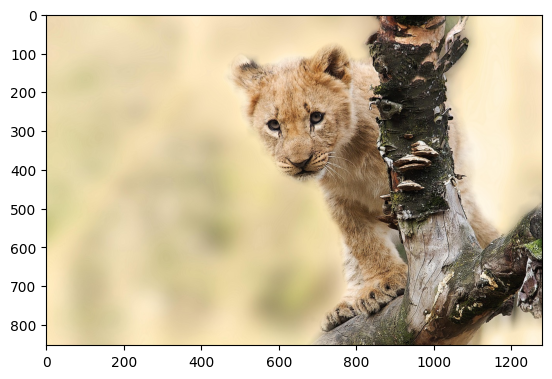

In [19]:
plt.imshow(image)
plt.show()

In [20]:
image_inputs = processor(images=image,return_tensors="pt")
pixel_values = image_inputs["pixel_values"]
pixel_values.shape, pixel_values.min(), pixel_values.max()

(torch.Size([1, 3, 224, 224]), tensor(-1.7923), tensor(1.9895))

In [21]:
with torch.inference_mode():
    output = clip.vision_model(pixel_values.to(device))
image_embeddings = output.pooler_output
image_embeddings.shape
    

torch.Size([1, 1024])

In [22]:
prompts = [
    "a photo of a lion",
    "a photo of a zebra"
]

text_inputs = processor(text=prompts,return_tensors="pt",padding=True)

In [23]:
text_inputs

{'input_ids': tensor([[49406,   320,  1125,   539,   320,  5567, 49407],
        [49406,   320,  1125,   539,   320, 22548, 49407]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1]])}

In [24]:
text_inputs = {k: v.to(device) for k,v in text_inputs.items()}

In [25]:
with torch.inference_mode():
    text_output = clip.text_model(**text_inputs)

text_embeddings = text_output.pooler_output
text_embeddings.shape

torch.Size([2, 768])

In [26]:
with torch.inference_mode():
    text_embeddings = clip.text_projection(text_embeddings)
    image_embeddings = clip.visual_projection(image_embeddings)

text_embeddings.shape, image_embeddings.shape

(torch.Size([2, 768]), torch.Size([1, 768]))

In [27]:
#Normalize the embeddings
text_embeddings = text_embeddings / text_embeddings.norm(p=2,dim=-1,keepdim=True)
image_embeddings = image_embeddings / image_embeddings.norm(p=2,dim=-1,keepdim=True)

#Calculate similarities and probability
similarities = 100*torch.matmul(text_embeddings,image_embeddings.T)
probabilities = similarities.softmax(dim=0).cpu()

print(probabilities)

tensor([[0.9479],
        [0.0521]])


## Zero-shot classification using clip directly

In [33]:
prompts = [
    "a photo of a lion",
    "a photo of a zebra",
    "a photo of a cat",
    "a photo of an adorable lion cub",
    "a puppy",
    "a lion behind a branch"
]

inputs = processor(
    text = prompts, images = image, return_tensors="pt",padding=True
)

inputs = {k: v.to(device) for k,v in inputs.items()}
outputs = clip(**inputs)
logits_per_image = outputs.logits_per_image

In [45]:
probabilities = logits_per_image.softmax(dim=1)
probabilities = probabilities[0].cpu().detach().tolist()

for prob,prompt in sorted(zip(probabilities,prompts),reverse=True):
    print(f"Prompt: {prompt}, with probability {prob*100:=2.0f}%")

Prompt: a photo of an adorable lion cub, with probability 84%
Prompt: a lion behind a branch, with probability 13%
Prompt: a photo of a lion, with probability  3%
Prompt: a photo of a zebra, with probability  0%
Prompt: a photo of a cat, with probability  0%
Prompt: a puppy, with probability  0%


In [47]:
from transformers import pipeline

classifier = pipeline(
    task = "zero-shot-image-classification",
    model = "openai/clip-vit-large-patch14",
    device = device
)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda


In [48]:
score = classifier(
    image,
    candidate_labels = prompts,
    hypothesis_template="{}" #This defines the expected format of prompts


)
score

[{'score': 0.8392907977104187, 'label': 'a photo of an adorable lion cub'},
 {'score': 0.1291804015636444, 'label': 'a lion behind a branch'},
 {'score': 0.02919219434261322, 'label': 'a photo of a lion'},
 {'score': 0.0016057866159826517, 'label': 'a photo of a zebra'},
 {'score': 0.0007013395661488175, 'label': 'a photo of a cat'},
 {'score': 2.9521021133405156e-05, 'label': 'a puppy'}]